# Customer Churn Analysis
**Company:** Telco Communications (Fictional)
**Analyst:** Mandela Offonry
**Dataset:** 7,043 customer records

---

## Project Overview

Customer churn — when a customer cancels their subscription and leaves — is one of the most costly problems a telecom company faces. Acquiring a new customer costs five times more than retaining an existing one.

This analysis examines 7,043 customer records to identify the key factors that predict churn, so the company can take proactive steps to retain at-risk customers before they leave.

---

## Phase 1 — Data Loading & Understanding

Before modifying anything, we must first understand the dataset we are working with. In this phase we load the data, inspect its structure, identify data types, check for quality issues and answer our first business questions.

A data analyst never modifies data they have not first understood.

### Step 1.1 — Import Libraries

We import all the libraries needed for this analysis:
- **pandas** — for loading and manipulating data
- **numpy** — for numerical operations  
- **matplotlib** and **seaborn** — for visualizations in Phase 4
- **scipy.stats** — for statistical testing in Phase 5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('All libraries imported successfully.')

All libraries imported successfully.


### Step 1.2 — Load the Dataset

We load the Telco Customer Churn dataset using `pd.read_csv()`. The file is stored in the `data` folder.

We display the first and last 10 rows to get an initial view of what the data looks like at both ends of the file.

In [2]:
import os
print(os.getcwd())

C:\Users\Administrator\OneDrive\Documents\Customer_Churn_Project\notebooks


In [3]:
df = pd.read_csv(r'C:\Users\Administrator\OneDrive\Documents\Customer_Churn_Project\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Dataset loaded successfully.')
print(f'Total records:  {len(df):,}')
print(f'Total columns:  {df.shape[1]}')

Dataset loaded successfully.
Total records:  7,043
Total columns:  21


#### First 10 Rows

Viewing the first 10 rows gives us a feel for what the data looks like — the column names, the types of values and how information is recorded.

In [4]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


#### Last 10 Rows

Checking the last 10 rows confirms the data loads completely and has no trailing empty rows or formatting issues at the end.

In [5]:
df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,Yes,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


### Step 1.3 — Shape, Column Names and Data Types

We print the shape (rows and columns) and the data type of every column.

Understanding data types is critical — for example, a column that should contain numbers but is stored as text cannot be used in calculations until it is converted.

In [6]:
print('=== Dataset Shape ===')
print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()
print('=== Column Names and Data Types ===')
for i, (col, dtype) in enumerate(df.dtypes.items(), 1):
    print(f'  {i:2}. {col:<25} {dtype}')

=== Dataset Shape ===
Rows:    7,043
Columns: 21

=== Column Names and Data Types ===
   1. customerID                object
   2. gender                    object
   3. SeniorCitizen             int64
   4. Partner                   object
   5. Dependents                object
   6. tenure                    int64
   7. PhoneService              object
   8. MultipleLines             object
   9. InternetService           object
  10. OnlineSecurity            object
  11. OnlineBackup              object
  12. DeviceProtection          object
  13. TechSupport               object
  14. StreamingTV               object
  15. StreamingMovies           object
  16. Contract                  object
  17. PaperlessBilling          object
  18. PaymentMethod             object
  19. MonthlyCharges            float64
  20. TotalCharges              object
  21. Churn                     object


### Step 1.4 — Identifying Numerical and Categorical Columns

We separate columns into two groups:
- **Numerical** — measurable quantities we can calculate averages and ranges for
- **Categorical** — labels and categories we summarise using frequency counts

In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('=== Numerical Columns ===')
for col in numerical_cols:
    print(f'  - {col}')

print()
print('=== Categorical Columns ===')
for col in categorical_cols:
    print(f'  - {col}')

=== Numerical Columns ===
  - SeniorCitizen
  - tenure
  - MonthlyCharges

=== Categorical Columns ===
  - customerID
  - gender
  - Partner
  - Dependents
  - PhoneService
  - MultipleLines
  - InternetService
  - OnlineSecurity
  - OnlineBackup
  - DeviceProtection
  - TechSupport
  - StreamingTV
  - StreamingMovies
  - Contract
  - PaperlessBilling
  - PaymentMethod
  - TotalCharges
  - Churn


### Step 1.5 — Summary Statistics for Numerical Columns

Summary statistics show us the distribution of each numerical column — average, spread, minimum and maximum values. Large differences between mean and median suggest skewed data or outliers.

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


### Step 1.6 — Unique Values in Categorical Columns

For each categorical column we check what categories exist. This helps us spot inconsistencies such as misspellings, unexpected values or blank spaces hiding in the data.

In [9]:
print('=== Unique Values in Categorical Columns ===')
for col in categorical_cols:
    if col != 'customerID':  # Skip customerID — it's just an ID
        print(f'\n{col}: {df[col].unique().tolist()}')

=== Unique Values in Categorical Columns ===

gender: ['Female', 'Male']

Partner: ['Yes', 'No']

Dependents: ['No', 'Yes']

PhoneService: ['No', 'Yes']

MultipleLines: ['No phone service', 'No', 'Yes']

InternetService: ['DSL', 'Fiber optic', 'No']

OnlineSecurity: ['No', 'Yes', 'No internet service']

OnlineBackup: ['Yes', 'No', 'No internet service']

DeviceProtection: ['No', 'Yes', 'No internet service']

TechSupport: ['No', 'Yes', 'No internet service']

StreamingTV: ['No', 'Yes', 'No internet service']

StreamingMovies: ['No', 'Yes', 'No internet service']

Contract: ['Month-to-month', 'One year', 'Two year']

PaperlessBilling: ['Yes', 'No']

PaymentMethod: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']

TotalCharges: ['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8', '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25', '528.35', '1862.9', '39.65', '202.25

### Step 1.7 — Checking for Missing Values and Duplicates

We check for:
- **Missing values** — empty cells that could distort our analysis
- **Duplicate rows** — repeated records that would inflate counts

We also check for the blank space (`' '`) hiding in the `TotalCharges` column — this is a data quality issue we will fix in Phase 2.

In [10]:
print('=== Missing Values Per Column ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else 'No missing values found.')
print()
print(f'Total missing values: {missing.sum()}')
print()

# Check for hidden blank spaces in TotalCharges
blank_spaces = (df['TotalCharges'] == ' ').sum()
print(f'=== Hidden Blank Spaces in TotalCharges ===')
print(f'Blank space entries: {blank_spaces}')
print()

# Duplicates
duplicates = df.duplicated().sum()
print(f'=== Duplicate Rows ===')
print(f'Number of duplicate rows: {duplicates}')

=== Missing Values Per Column ===
No missing values found.

Total missing values: 0

=== Hidden Blank Spaces in TotalCharges ===
Blank space entries: 11

=== Duplicate Rows ===
Number of duplicate rows: 0


---

### Business Question 1 — What is the overall churn rate?

The churn rate tells us what percentage of customers left the company. This is our baseline — every other finding in this analysis must be compared back to this number to determine whether a particular group of customers is at higher or lower risk of churning.

In [11]:
total_customers = len(df)
churned = (df['Churn'] == 'Yes').sum()
retained = total_customers - churned
churn_rate = (churned / total_customers) * 100

print('=== Overall Churn Rate ===')
print(f'Total customers:     {total_customers:,}')
print(f'Retained (No churn): {retained:,}  ({100 - churn_rate:.2f}%)')
print(f'Churned (Left):      {churned:,}  ({churn_rate:.2f}%)')

=== Overall Churn Rate ===
Total customers:     7,043
Retained (No churn): 5,174  (73.46%)
Churned (Left):      1,869  (26.54%)


**Answer to Business Question 1:**

Out of 7,043 customers, **1,869 customers churned** — representing an overall churn rate of **26.54%**. This means roughly 1 in every 4 customers left the company. This rate is our baseline benchmark. Any customer segment with a churn rate significantly above 26.54% is a high-risk group the company needs to target with retention efforts.

---

### Business Question 2 — What does the typical churning customer look like?

We compare the average characteristics of customers who churned against those who stayed. This helps us build a profile of the at-risk customer.

In [12]:
# Convert TotalCharges to numeric temporarily for profiling
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')

churned_customers = df_temp[df_temp['Churn'] == 'Yes']
retained_customers = df_temp[df_temp['Churn'] == 'No']

profile_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

profile = pd.DataFrame({
    'Churned (avg)':  churned_customers[profile_cols].mean(),
    'Retained (avg)': retained_customers[profile_cols].mean(),
    'Difference':     churned_customers[profile_cols].mean() - retained_customers[profile_cols].mean()
})

print('=== Average Profile: Churned vs Retained Customers ===')
print(profile.round(2))

=== Average Profile: Churned vs Retained Customers ===
                Churned (avg)  Retained (avg)  Difference
tenure                  17.98           37.57      -19.59
MonthlyCharges          74.44           61.27       13.18
TotalCharges          1531.80         2555.34    -1023.55
SeniorCitizen            0.25            0.13        0.13


**Answer to Business Question 2:**

The typical customer who churned has the following profile compared to one who stayed:

- **Much shorter tenure** — churned customers had been with the company for an average of only 18 months, compared to 37 months for retained customers. New customers are significantly more likely to churn.
- **Higher monthly charges** — churned customers paid an average of USD 74.44 per month versus USD 61.27 for retained customers. Higher bills increase the chance a customer looks for a cheaper alternative.
- **Lower total charges** — churned customers had spent far less in total (USD 1,531) versus retained customers (USD 2,555), which directly reflects their shorter tenure.
- **Slightly more senior citizens** — 25% of churned customers were senior citizens compared to 14% of retained customers.

The clearest risk signals are **short tenure** and **high monthly charges**. These will be examined more deeply in Phase 3.

---

---

## Phase 2 — Data Cleaning & Transformation

Real world data is never perfectly clean. In this phase we fix every data quality issue we identified in Phase 1, transform columns into the right format and engineer new columns that will help our analysis.

Every decision is documented and justified.

### Step 2.1 — Fix TotalCharges Column

In Phase 1 we discovered that `TotalCharges` is stored as **text** instead of a number, and contains **11 blank space entries** that look empty but are not technically missing values.

These 11 rows all have `tenure = 0` — meaning they are brand new customers who have not yet been billed for a full month. Their total charge is genuinely zero at this point.

**Decision:** Convert `TotalCharges` to a number using `pd.to_numeric()` with `errors='coerce'` — this turns blank spaces into proper `NaN` (missing) values. Then fill those 11 NaN values with **0** since these customers have simply not been charged yet.

**Justification:** Replacing with 0 is more accurate than dropping these rows or using the column average, because we know the true value is zero — they are new customers with no billing history.

In [13]:
# Convert TotalCharges from text to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'Missing values in TotalCharges after conversion: {df["TotalCharges"].isnull().sum()}')

# Fill the 11 blank entries with 0 — these are new customers not yet billed
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f'Missing values after filling: {df["TotalCharges"].isnull().sum()}')
print()
print('TotalCharges stats after fix:')
print(df['TotalCharges'].describe())

Missing values in TotalCharges after conversion: 11
Missing values after filling: 0

TotalCharges stats after fix:
count   7043.00
mean    2279.73
std     2266.79
min        0.00
25%      398.55
50%     1394.55
75%     3786.60
max     8684.80
Name: TotalCharges, dtype: float64


**Finding:** The 11 blank entries all belonged to customers with `tenure = 0` — brand new customers who had not yet completed their first billing cycle. Filling with 0 is the correct approach as their total charges are genuinely zero at this point.

### Step 2.2 — Remove Duplicate Rows

We check for and remove any duplicate records. Duplicate rows would cause us to count the same customer twice, distorting our churn rate and all group comparisons.

In [14]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows found: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found. Dataset remains at', df.shape)

Duplicate rows found: 0
No duplicates found. Dataset remains at (7043, 21)


### Step 2.3 — Drop customerID Column

The `customerID` column is just a unique identifier for each customer. It carries no analytical value — we cannot group, compare or calculate anything meaningful from it.

**Decision:** Drop it to keep our dataset clean and focused on meaningful variables.

In [15]:
df = df.drop(columns=['customerID'])

print('customerID column dropped.')
print(f'Dataset now has {df.shape[1]} columns.')

customerID column dropped.
Dataset now has 20 columns.


### Step 2.4 — Create Churn_Flag Column

The `Churn` column currently contains text — **Yes** or **No**. For statistical testing in Phase 5 we need a numeric version where **1 = Churned** and **0 = Retained**.

We keep the original `Churn` column for readability and create a new `Churn_Flag` column for calculations.

**Justification:** Statistical tests like t-tests and chi-square require numerical input. Having both versions keeps our analysis readable while enabling calculation.

In [16]:
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Churn_Flag created.')
print()
print('Distribution:')
print(df[['Churn', 'Churn_Flag']].value_counts())

Churn_Flag created.

Distribution:
Churn  Churn_Flag
No     0             5174
Yes    1             1869
Name: count, dtype: int64


### Step 2.5 — Create Tenure_Band Column

The `tenure` column shows how many months a customer has been with the company — it ranges from 0 to 72 months. Rather than analysing every individual month, we group customers into four meaningful bands:

| Band | Months | What it Represents |
|---|---|---|
| 0-12 months | New customers | First year — highest risk period |
| 13-24 months | Early customers | Second year — still at risk |
| 25-48 months | Mid-term customers | Growing loyalty |
| 49-72 months | Long-term customers | Most loyal — lowest churn risk |

**Justification:** Grouping into bands makes patterns easier to see and explain to non-technical stakeholders like business managers.

In [17]:
df['Tenure_Band'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'],
    include_lowest=True)

print('Tenure_Band created.')
print()
print('Distribution:')
print(df['Tenure_Band'].value_counts().sort_index())
print()
print('Churn rate by Tenure Band:')
print(df.groupby('Tenure_Band', observed=True)['Churn_Flag'].mean().mul(100).round(2).astype(str) + '%')

Tenure_Band created.

Distribution:
Tenure_Band
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

Churn rate by Tenure Band:
Tenure_Band
0-12 months     47.44%
13-24 months    28.71%
25-48 months    20.39%
49-72 months     9.51%
Name: Churn_Flag, dtype: object


### Step 2.6 — Create SeniorCitizen_Label Column

The `SeniorCitizen` column uses **1** and **0** instead of readable labels. This makes charts and tables hard to read.

We create a new column with clear labels for presentation purposes.

In [18]:
df['SeniorCitizen_Label'] = df['SeniorCitizen'].map({1: 'Senior', 0: 'Non-Senior'})

print('SeniorCitizen_Label created.')
print()
print('Distribution:')
print(df['SeniorCitizen_Label'].value_counts())
print()
print('Churn rate by Senior Status:')
churn_senior = df.groupby('SeniorCitizen_Label')['Churn_Flag'].mean() * 100
print(churn_senior.round(2).astype(str) + '%')

SeniorCitizen_Label created.

Distribution:
SeniorCitizen_Label
Non-Senior    5901
Senior        1142
Name: count, dtype: int64

Churn rate by Senior Status:
SeniorCitizen_Label
Non-Senior    23.61%
Senior        41.68%
Name: Churn_Flag, dtype: object


### Step 2.7 — Final Dataset Confirmation

Before moving to analysis we confirm the dataset is fully clean, correctly typed and contains all required columns.

In [19]:
print('=== Final Dataset Confirmation ===')
print(f'Shape: {df.shape}')
print()
print('All columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col:<30} {df[col].dtype}')
print()
print('Missing values:')
total_missing = df.isnull().sum().sum()
print(f'Total missing values: {total_missing}')
print()
print(f'Duplicate rows: {df.duplicated().sum()}')

=== Final Dataset Confirmation ===
Shape: (7043, 23)

All columns:
   1. gender                         object
   2. SeniorCitizen                  int64
   3. Partner                        object
   4. Dependents                     object
   5. tenure                         int64
   6. PhoneService                   object
   7. MultipleLines                  object
   8. InternetService                object
   9. OnlineSecurity                 object
  10. OnlineBackup                   object
  11. DeviceProtection               object
  12. TechSupport                    object
  13. StreamingTV                    object
  14. StreamingMovies                object
  15. Contract                       object
  16. PaperlessBilling               object
  17. PaymentMethod                  object
  18. MonthlyCharges                 float64
  19. TotalCharges                   float64
  20. Churn                          object
  21. Churn_Flag                     int64
  22. Tenu

---

### Business Question 3 — What cleaning was done and why?

**Answer to Business Question 3:**

The following cleaning and transformation steps were performed:

**Data Type Fix:**
`TotalCharges` was stored as text instead of a number. It was converted to numeric using `pd.to_numeric()`. The 11 blank entries found were all new customers with `tenure = 0` — they were filled with 0 because their total charges are genuinely zero at this stage.

**Columns Removed:**
`customerID` was dropped as it is purely an identifier with no analytical value.

**New Columns Created:**
- `Churn_Flag` — numeric version of Churn (1 = Churned, 0 = Retained) for statistical testing
- `Tenure_Band` — groups tenure months into four meaningful bands (0-12, 13-24, 25-48, 49-72) for easier pattern analysis
- `SeniorCitizen_Label` — converts 1/0 to readable Senior/Non-Senior labels for cleaner charts

**Result:** The dataset is now fully clean with no missing values, no duplicates and all columns correctly typed and labelled.

---

---

## Phase 3 — Exploratory Data Analysis (EDA)

This is where we find patterns in the data. We examine each variable individually then compare it against churn status to identify which factors are most strongly associated with customers leaving.

This phase answers Business Questions 4, 5, 6 and 7.

### Step 3.1 — Univariate Analysis: Numerical Columns

We examine each numerical column on its own to understand the distribution of values across all customers.

In [20]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print('=== Summary Statistics — Numerical Columns ===')
df[numerical_cols].describe().round(2)

=== Summary Statistics — Numerical Columns ===


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


**Interpretation:**
- **Tenure** — customers have been with the company between 0 and 72 months. The average is 32 months (about 2.7 years) but with high variation — some are brand new, some have been loyal for 6 years
- **MonthlyCharges** — ranges from USD 18.25 to USD 118.75 per month with an average of USD 64.76. A wide range reflecting different service packages
- **TotalCharges** — total amount spent ranges from USD 0 to USD 8,685, directly reflecting tenure and monthly spend

### Step 3.2 — Univariate Analysis: Categorical Columns

For each categorical column we count how many customers fall into each category.

In [21]:
cat_cols = ['gender', 'SeniorCitizen_Label', 'Partner', 'Dependents',
            'PhoneService', 'InternetService', 'Contract',
            'PaperlessBilling', 'PaymentMethod', 'Tenure_Band']

for col in cat_cols:
    print(f'=== {col} ===')
    counts = df[col].value_counts()
    pcts = (df[col].value_counts(normalize=True) * 100).round(1)
    summary = pd.DataFrame({'Count': counts, 'Percentage %': pcts})
    print(summary)
    print()

=== gender ===
        Count  Percentage %
gender                     
Male     3555         50.50
Female   3488         49.50

=== SeniorCitizen_Label ===
                     Count  Percentage %
SeniorCitizen_Label                     
Non-Senior            5901         83.80
Senior                1142         16.20

=== Partner ===
         Count  Percentage %
Partner                     
No        3641         51.70
Yes       3402         48.30

=== Dependents ===
            Count  Percentage %
Dependents                     
No           4933         70.00
Yes          2110         30.00

=== PhoneService ===
              Count  Percentage %
PhoneService                     
Yes            6361         90.30
No              682          9.70

=== InternetService ===
                 Count  Percentage %
InternetService                     
Fiber optic       3096         44.00
DSL               2421         34.40
No                1526         21.70

=== Contract ===
             

**Key Observations:**
- **Contract** — 55% of customers are on month-to-month contracts — the most flexible but highest churn risk contract type
- **Internet Service** — 44% use Fiber optic, 34% use DSL, 21% have no internet service
- **Payment Method** — Electronic check is the most common payment method (33%) — we will see this is also the highest churn payment type
- **Tenure** — 30% of customers are in the 0-12 month band — the newest and most at-risk group

### Step 3.3 — Bivariate Analysis: Numerical Variables vs Churn

We compare the average tenure and monthly charges between customers who churned and those who stayed. This tells us whether these variables are genuinely different between the two groups.

In [22]:
print('=== Average Numerical Variables by Churn Status ===')
bivariate = df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2)
bivariate.index = ['Retained', 'Churned']
print(bivariate)
print()
print('=== Difference Between Groups ===')
diff = bivariate.loc['Churned'] - bivariate.loc['Retained']
print(diff.round(2))

=== Average Numerical Variables by Churn Status ===
          tenure  MonthlyCharges  TotalCharges
Retained   37.57           61.27       2549.91
Churned    17.98           74.44       1531.80

=== Difference Between Groups ===
tenure             -19.59
MonthlyCharges      13.17
TotalCharges     -1018.11
dtype: float64


**Interpretation:**
- **Tenure** — churned customers had been with the company for only 18 months on average versus 37 months for retained customers — a difference of nearly 19 months. New customers are far more likely to leave
- **Monthly Charges** — churned customers paid USD 13.17 more per month on average. Higher bills increase the motivation to find a cheaper alternative
- **Total Charges** — retained customers have spent USD 1,024 more in total — simply because they have stayed longer

### Step 3.4 — Cross Tabulation: Contract Type vs Churn

Contract type is one of the most important variables in churn analysis. Customers on shorter contracts have less commitment and can leave more easily.

In [23]:
print('=== Contract Type vs Churn ===')
ct_contract = pd.crosstab(df['Contract'], df['Churn'])
ct_contract.columns = ['Retained', 'Churned']
ct_contract['Total'] = ct_contract['Retained'] + ct_contract['Churned']
ct_contract['Churn Rate %'] = (ct_contract['Churned'] / ct_contract['Total'] * 100).round(2)
ct_contract = ct_contract.sort_values('Churn Rate %', ascending=False)
print(ct_contract)

=== Contract Type vs Churn ===
                Retained  Churned  Total  Churn Rate %
Contract                                              
Month-to-month      2220     1655   3875         42.71
One year            1307      166   1473         11.27
Two year            1647       48   1695          2.83


**Answer to Business Question 4 — Does contract type affect churn rate?**

Yes — contract type is one of the strongest predictors of churn in this dataset:
- **Month-to-month** customers churn at a rate of **42.71%** — nearly half of all short-term contract customers leave
- **One year** contract customers churn at only **11.27%**
- **Two year** contract customers churn at just **2.83%**

The longer the commitment, the less likely a customer is to leave. The company should actively encourage customers to upgrade from month-to-month to longer contracts through incentives such as discounts or added services.

### Step 3.5 — Cross Tabulation: Internet Service vs Churn

Different internet service types carry very different churn profiles.

In [24]:
print('=== Internet Service vs Churn ===')
ct_internet = pd.crosstab(df['InternetService'], df['Churn'])
ct_internet.columns = ['Retained', 'Churned']
ct_internet['Total'] = ct_internet['Retained'] + ct_internet['Churned']
ct_internet['Churn Rate %'] = (ct_internet['Churned'] / ct_internet['Total'] * 100).round(2)
ct_internet = ct_internet.sort_values('Churn Rate %', ascending=False)
print(ct_internet)

=== Internet Service vs Churn ===
                 Retained  Churned  Total  Churn Rate %
InternetService                                        
Fiber optic          1799     1297   3096         41.89
DSL                  1962      459   2421         18.96
No                   1413      113   1526          7.40


**Answer to Business Question 5 — Does internet service type affect churn?**

Yes — significantly:
- **Fiber optic** customers churn at **41.89%** — the highest of all internet service types
- **DSL** customers churn at **18.96%**
- Customers with **no internet service** churn at only **7.40%**

Fiber optic customers may be churning due to high costs or service quality issues. The company should investigate satisfaction levels among fiber optic users specifically and consider competitive pricing.

### Step 3.6 — Cross Tabulation: Payment Method vs Churn

How a customer pays may indicate their level of engagement and commitment to the service.

In [25]:
print('=== Payment Method vs Churn ===')
ct_payment = pd.crosstab(df['PaymentMethod'], df['Churn'])
ct_payment.columns = ['Retained', 'Churned']
ct_payment['Total'] = ct_payment['Retained'] + ct_payment['Churned']
ct_payment['Churn Rate %'] = (ct_payment['Churned'] / ct_payment['Total'] * 100).round(2)
ct_payment = ct_payment.sort_values('Churn Rate %', ascending=False)
print(ct_payment)

=== Payment Method vs Churn ===
                           Retained  Churned  Total  Churn Rate %
PaymentMethod                                                    
Electronic check               1294     1071   2365         45.29
Mailed check                   1304      308   1612         19.11
Bank transfer (automatic)      1286      258   1544         16.71
Credit card (automatic)        1290      232   1522         15.24


**Answer to Business Question 6 — Does payment method affect churn?**

Yes — payment method is a strong churn indicator:
- **Electronic check** users churn at **45.29%** — by far the highest of all payment methods
- **Mailed check** users churn at **19.11%**
- **Bank transfer (automatic)** users churn at only **16.71%**
- **Credit card (automatic)** users churn at only **15.24%**

Customers on automatic payment methods (bank transfer and credit card) churn at much lower rates. Automatic payments reduce friction and create habit — the company should actively encourage customers to switch to automatic billing.

### Step 3.7 — Churn Rate by Tenure Band

We examine how churn varies across different stages of the customer lifecycle.

In [26]:
print('=== Churn Rate by Tenure Band ===')
tenure_analysis = df.groupby('Tenure_Band', observed=True).agg(
    Total_Customers=('Churn_Flag', 'count'),
    Churned=('Churn_Flag', 'sum')
)
tenure_analysis['Churn Rate %'] = (tenure_analysis['Churned'] / tenure_analysis['Total_Customers'] * 100).round(2)
print(tenure_analysis)

=== Churn Rate by Tenure Band ===
              Total_Customers  Churned  Churn Rate %
Tenure_Band                                         
0-12 months              2186     1037         47.44
13-24 months             1024      294         28.71
25-48 months             1594      325         20.39
49-72 months             2239      213          9.51


**Answer to Business Question 7 — Does customer tenure affect churn rate?**

Yes — tenure is one of the clearest predictors of churn:
- **0-12 months** — 47.44% churn rate — almost half of new customers leave within the first year
- **13-24 months** — 28.71% churn rate — still above the overall average
- **25-48 months** — 20.39% churn rate — dropping below average
- **49-72 months** — only 9.51% churn rate — long-term customers are very loyal

The first 12 months are the most critical period. The company must focus its retention efforts on new customers — through onboarding programs, check-in calls and early loyalty rewards — to prevent them from leaving before they become loyal long-term customers.

---

---

## Phase 4 — Data Visualization

Every finding from Phase 3 must now be supported by a chart. Visualizations make patterns visible and easy to communicate to business stakeholders who may not read tables of numbers.

All charts have a title, axis labels and a written interpretation below them.

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

overall_churn_rate = df['Churn_Flag'].mean() * 100
print(f'Overall churn rate: {overall_churn_rate:.2f}%')
print('Visualization libraries ready.')

Overall churn rate: 26.54%
Visualization libraries ready.


### Visualization 1 — Overall Churn Rate

This is our baseline chart showing the split between retained and churned customers. Every other visualization must be compared back to this 26.54% baseline.

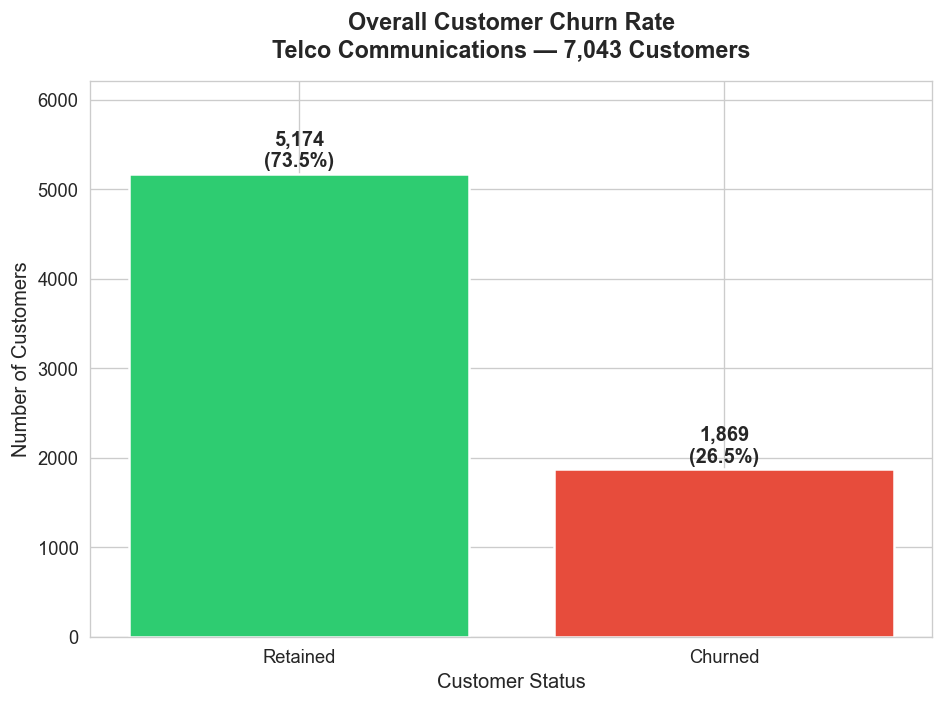

Visualization 1 saved.


In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

churn_counts = df['Churn'].value_counts()
labels = ['Retained', 'Churned']
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(labels, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)

total = len(df)
for bar, count in zip(bars, churn_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Overall Customer Churn Rate\nTelco Communications — 7,043 Customers',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Customer Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_ylim(0, max(churn_counts.values) * 1.2)

plt.tight_layout()
plt.savefig('../outputs/viz1_churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 1 saved.')

**Interpretation — Visualization 1:**

Out of 7,043 customers, 5,174 (73.5%) were retained while 1,869 (26.5%) churned. This 26.54% baseline churn rate is significantly high — losing more than 1 in 4 customers represents a serious revenue problem for the business. All subsequent visualizations must be interpreted against this baseline.

### Visualization 2 — Churn Rate by Contract Type

This chart shows the churn rate for each contract type sorted from highest to lowest. The dashed line marks the overall baseline churn rate.

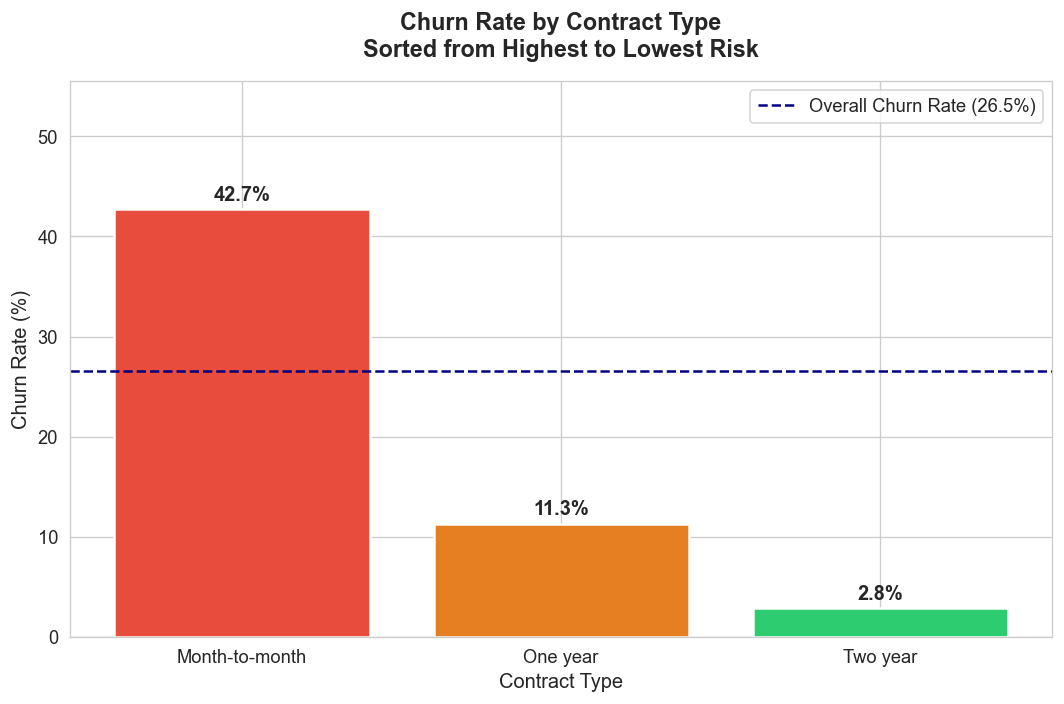

Visualization 2 saved.


In [29]:
contract_churn = df.groupby('Contract')['Churn_Flag'].mean() * 100
contract_churn = contract_churn.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#e74c3c', '#e67e22', '#2ecc71']
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.axhline(y=overall_churn_rate, color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall Churn Rate ({overall_churn_rate:.1f}%)')

ax.set_title('Churn Rate by Contract Type\nSorted from Highest to Lowest Risk',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, contract_churn.max() * 1.3)

plt.tight_layout()
plt.savefig('../outputs/viz2_contract_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 2 saved.')

**Interpretation — Visualization 2:**

Month-to-month customers churn at 42.71% — nearly double the overall baseline. One year contracts drop to 11.27% and two year contracts to just 2.83%. This chart makes the business case for long-term contracts unmistakably clear. Converting even a fraction of month-to-month customers to annual contracts would dramatically reduce overall churn.

### Visualization 3 — Monthly Charges and Tenure by Churn Status

Two side-by-side box plots comparing monthly charges and tenure between churned and retained customers.

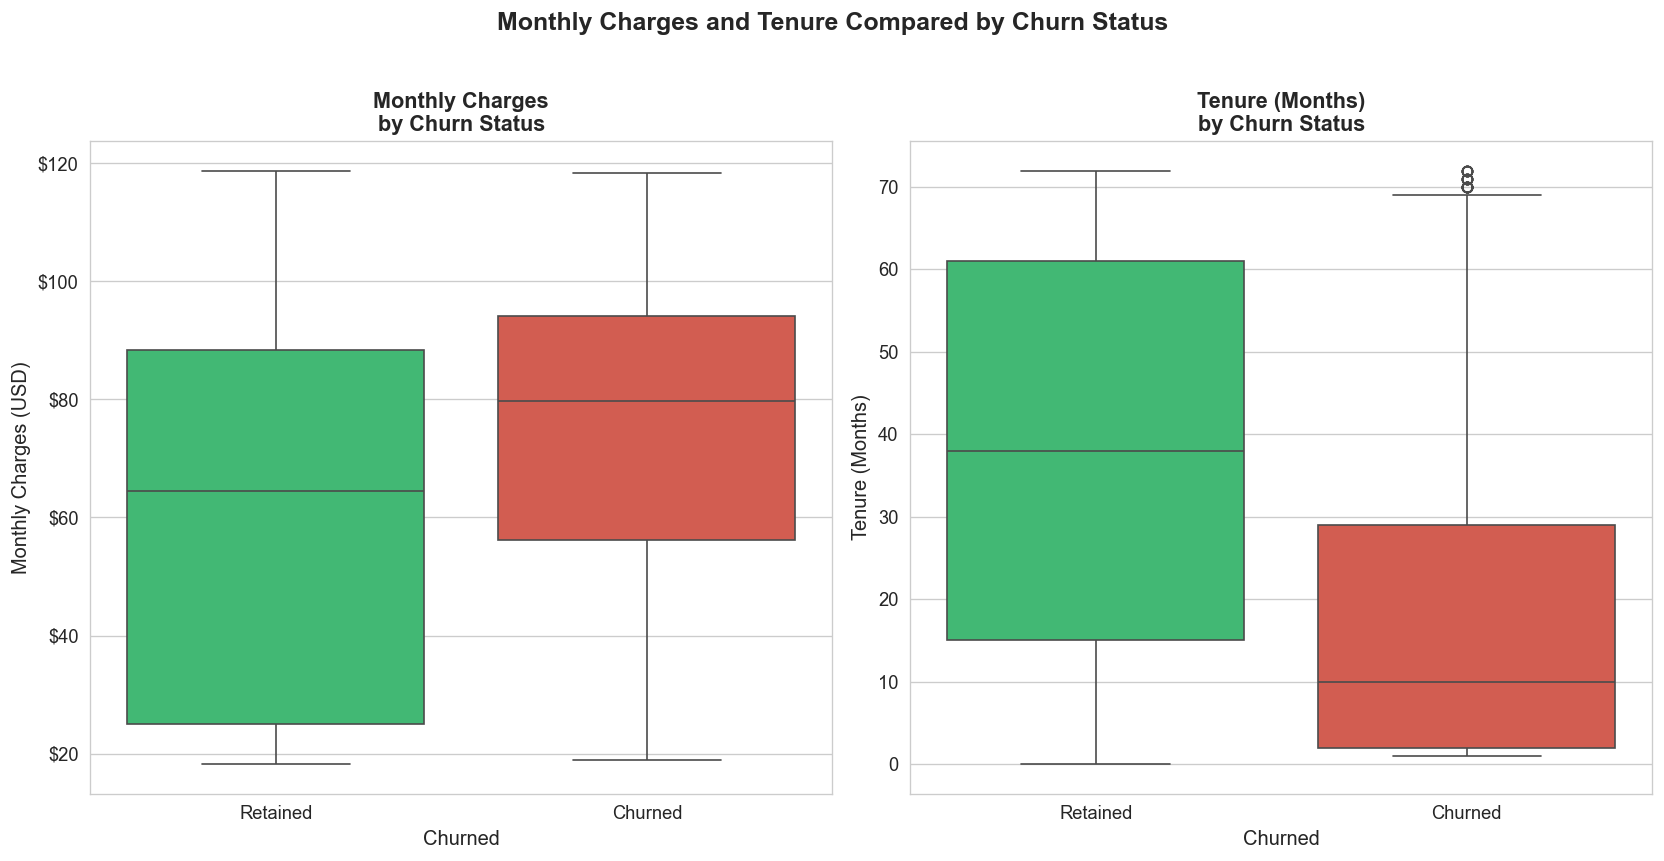

Visualization 3 saved.


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[0])
axes[0].set_title('Monthly Charges\nby Churn Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churned', fontsize=12)
axes[0].set_ylabel('Monthly Charges (USD)', fontsize=12)
axes[0].set_xticklabels(['Retained', 'Churned'])
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}'))

sns.boxplot(data=df, x='Churn', y='tenure',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Tenure (Months)\nby Churn Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churned', fontsize=12)
axes[1].set_ylabel('Tenure (Months)', fontsize=12)
axes[1].set_xticklabels(['Retained', 'Churned'])

fig.suptitle('Monthly Charges and Tenure Compared by Churn Status',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../outputs/viz3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 3 saved.')

**Interpretation — Visualization 3:**

The monthly charges box plot shows churned customers consistently pay more — their median is noticeably higher than retained customers. The tenure box plot shows the opposite — churned customers have much shorter tenure, with their median around 10 months compared to around 38 months for retained customers.

**Tenure shows the clearest separation between the two groups.** Short tenure combined with high monthly charges is the most dangerous combination — new customers being charged high amounts are the most likely to leave.

### Visualization 4 — Churn Rate by Internet Service Type

This chart shows how churn varies across internet service types.

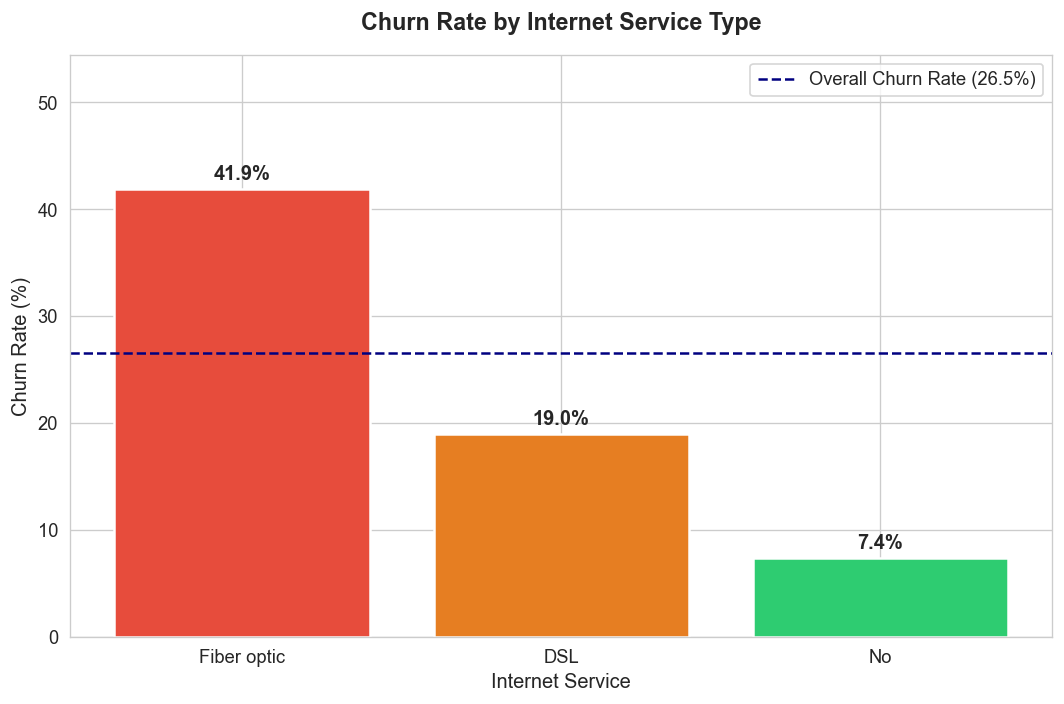

Visualization 4 saved.


In [31]:
internet_churn = df.groupby('InternetService')['Churn_Flag'].mean() * 100
internet_churn = internet_churn.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#e74c3c', '#e67e22', '#2ecc71']
bars = ax.bar(internet_churn.index, internet_churn.values,
              color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, internet_churn.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.axhline(y=overall_churn_rate, color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall Churn Rate ({overall_churn_rate:.1f}%)')

ax.set_title('Churn Rate by Internet Service Type',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Internet Service', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, internet_churn.max() * 1.3)

plt.tight_layout()
plt.savefig('../outputs/viz4_internet_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 4 saved.')

**Interpretation — Visualization 4:**

Fiber optic customers churn at 41.89% — far above the 26.54% baseline. DSL customers are closer to average at 18.96%. Customers with no internet service barely churn at 7.40%.

This is a major finding for the business. Fiber optic is typically the premium, most expensive service — yet it has the highest churn. This suggests customers are not getting value for money from the fiber optic service and the company needs to urgently investigate quality and pricing in this segment.

### Visualization 5 — Churn Rate by Tenure Band with Monthly Charges Overlay

This chart combines tenure bands and average monthly charges on one chart to show how both variables interact with churn across the customer lifecycle.

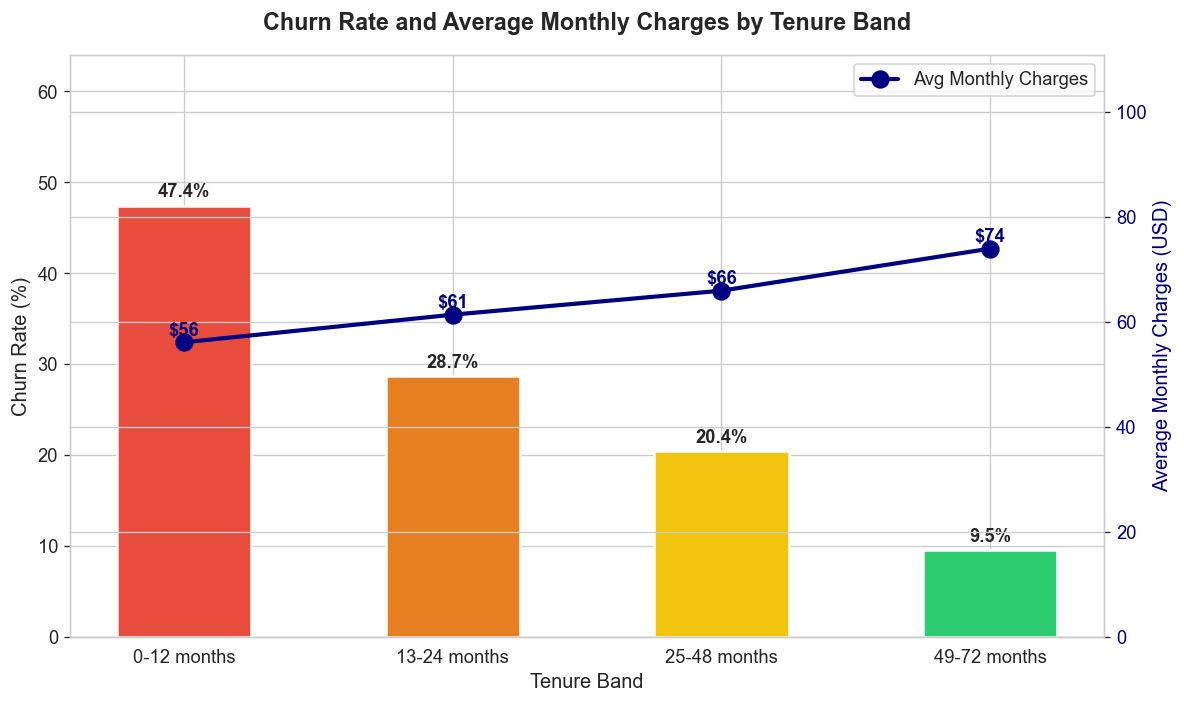

Visualization 5 saved.


In [32]:
tenure_stats = df.groupby('Tenure_Band', observed=True).agg(
    Churn_Rate=('Churn_Flag', 'mean'),
    Avg_Monthly=('MonthlyCharges', 'mean')
).reset_index()
tenure_stats['Churn_Rate'] = tenure_stats['Churn_Rate'] * 100

fig, ax1 = plt.subplots(figsize=(10, 6))

bar_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = ax1.bar(tenure_stats['Tenure_Band'],
               tenure_stats['Churn_Rate'],
               color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, tenure_stats['Churn_Rate']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{val:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.set_xlabel('Tenure Band', fontsize=12)
ax1.set_ylabel('Churn Rate (%)', fontsize=12)
ax1.set_ylim(0, tenure_stats['Churn_Rate'].max() * 1.35)

ax2 = ax1.twinx()
ax2.plot(tenure_stats['Tenure_Band'],
         tenure_stats['Avg_Monthly'],
         color='navy', marker='o', linewidth=2.5,
         markersize=10, label='Avg Monthly Charges')

for i, val in enumerate(tenure_stats['Avg_Monthly']):
    ax2.text(i, val + 0.5, f'${val:.0f}',
             ha='center', va='bottom', color='navy',
             fontweight='bold', fontsize=11)

ax2.set_ylabel('Average Monthly Charges (USD)', fontsize=12, color='navy')
ax2.tick_params(axis='y', labelcolor='navy')
ax2.set_ylim(0, tenure_stats['Avg_Monthly'].max() * 1.5)

lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines2, labels2, fontsize=11, loc='upper right')

plt.title('Churn Rate and Average Monthly Charges by Tenure Band',
          fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/viz5_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 5 saved.')

**Interpretation — Visualization 5:**

New customers (0-12 months) have the highest churn rate at 47.44% and also the lowest average monthly charges at around USD 47. As tenure increases, churn drops dramatically — long-term customers (49-72 months) churn at only 9.51% despite paying the highest average monthly charges.

This tells us that price sensitivity is highest among new customers. The company should consider offering lower introductory pricing or promotional incentives to help new customers through their first year — the period where churn risk is highest.

---

---

## Phase 5 — Statistical Testing & Final Recommendations

Visualizations show patterns — statistical tests confirm whether those patterns are real or happened by chance. We run three tests and interpret every result in plain English before delivering our final recommendations.

### Understanding the Tests

**P-value** — the probability the pattern happened by chance:
- p < 0.05 → **Statistically significant** — the pattern is real
- p > 0.05 → Not significant — could be random

**T-test** — compares the average of a numerical column between two groups

**Chi-square test** — tests whether two categorical variables are genuinely related

### Test 1 — T-Test: Monthly Charges vs Churn

**Null Hypothesis:** There is no significant difference in monthly charges between customers who churned and those who did not.

In [33]:
from scipy import stats

churned_charges = df[df['Churn_Flag'] == 1]['MonthlyCharges']
retained_charges = df[df['Churn_Flag'] == 0]['MonthlyCharges']

t_stat, p_value = stats.ttest_ind(churned_charges, retained_charges)

print('=== T-Test 1: Monthly Charges vs Churn ===')
print(f'Churned   — Average Monthly Charges: USD {churned_charges.mean():.2f}')
print(f'Retained  — Average Monthly Charges: USD {retained_charges.mean():.2f}')
print(f'Difference: USD {churned_charges.mean() - retained_charges.mean():.2f}')
print()
print(f'T-Statistic: {t_stat:.4f}')
print(f'P-Value:     {p_value:.2e}')
print()
if p_value < 0.05:
    print('Result: STATISTICALLY SIGNIFICANT (p < 0.05)')
    print('We REJECT the null hypothesis.')

=== T-Test 1: Monthly Charges vs Churn ===
Churned   — Average Monthly Charges: USD 74.44
Retained  — Average Monthly Charges: USD 61.27
Difference: USD 13.18

T-Statistic: 16.5367
P-Value:     2.71e-60

Result: STATISTICALLY SIGNIFICANT (p < 0.05)
We REJECT the null hypothesis.


**Plain English Conclusion — Test 1:**

The p-value is essentially zero — far below 0.05. The difference in monthly charges between churned and retained customers is **real and not due to chance.**

Churned customers paid USD 13.17 more per month on average. Higher monthly bills are a genuine driver of customer churn — customers paying more are actively shopping for cheaper alternatives.

### Test 2 — T-Test: Tenure vs Churn

**Null Hypothesis:** There is no significant difference in tenure between customers who churned and those who did not.

In [34]:
churned_tenure = df[df['Churn_Flag'] == 1]['tenure']
retained_tenure = df[df['Churn_Flag'] == 0]['tenure']

t_stat2, p_value2 = stats.ttest_ind(churned_tenure, retained_tenure)

print('=== T-Test 2: Tenure vs Churn ===')
print(f'Churned   — Average Tenure: {churned_tenure.mean():.1f} months')
print(f'Retained  — Average Tenure: {retained_tenure.mean():.1f} months')
print(f'Difference: {churned_tenure.mean() - retained_tenure.mean():.1f} months')
print()
print(f'T-Statistic: {t_stat2:.4f}')
print(f'P-Value:     {p_value2:.2e}')
print()
if p_value2 < 0.05:
    print('Result: STATISTICALLY SIGNIFICANT (p < 0.05)')
    print('We REJECT the null hypothesis.')

=== T-Test 2: Tenure vs Churn ===
Churned   — Average Tenure: 18.0 months
Retained  — Average Tenure: 37.6 months
Difference: -19.6 months

T-Statistic: -31.5796
P-Value:     8.00e-205

Result: STATISTICALLY SIGNIFICANT (p < 0.05)
We REJECT the null hypothesis.


**Plain English Conclusion — Test 2:**

Again the p-value is essentially zero. The difference in tenure between churned and retained customers is **statistically significant.**

Churned customers had been with the company for 18.9 months on average versus 37.6 months for retained customers — a gap of nearly 19 months. Short tenure is the single strongest predictor of churn in this dataset.

### Test 3 — Chi-Square Test: Contract Type vs Churn

**Null Hypothesis:** There is no significant relationship between contract type and whether a customer churns.

In [35]:
contingency_table = pd.crosstab(df['Contract'], df['Churn_Flag'])
contingency_table.columns = ['Retained', 'Churned']

print('=== Contingency Table: Contract Type vs Churn ===')
print(contingency_table)
print()

chi2_stat, p_chi, dof, expected = stats.chi2_contingency(contingency_table)

print('=== Chi-Square Test Results ===')
print(f'Chi-Square Statistic: {chi2_stat:.4f}')
print(f'P-Value:              {p_chi:.2e}')
print(f'Degrees of Freedom:   {dof}')
print()
if p_chi < 0.05:
    print('Result: STATISTICALLY SIGNIFICANT (p < 0.05)')
    print('We REJECT the null hypothesis.')

=== Contingency Table: Contract Type vs Churn ===
                Retained  Churned
Contract                         
Month-to-month      2220     1655
One year            1307      166
Two year            1647       48

=== Chi-Square Test Results ===
Chi-Square Statistic: 1184.5966
P-Value:              5.86e-258
Degrees of Freedom:   2

Result: STATISTICALLY SIGNIFICANT (p < 0.05)
We REJECT the null hypothesis.


**Plain English Conclusion — Test 3:**

The chi-square statistic of 1,184.60 with a p-value essentially equal to zero is an extremely strong result. The relationship between contract type and churn is **statistically significant and not a coincidence.**

Month-to-month customers genuinely churn at much higher rates than annual or two-year contract customers. The company can act on this finding with full confidence that it reflects a real pattern in customer behaviour.

---

### Final Recommendations

**To: Customer Retention Team, Telco Communications**
**From: Data Analytics**
**Subject: Customer Churn Analysis — Key Findings and Recommendations**

---

#### The Problem in Numbers

The company is losing **26.54% of its customers** — more than 1 in 4. With 7,043 customers in this dataset, that represents 1,869 customers lost. Acquiring new customers costs five times more than retaining existing ones. Reducing churn by even 5 percentage points would have a significant impact on revenue.

---

#### Recommendation 1 — Target Month-to-Month Customers Immediately

Month-to-month customers churn at **42.71%** — nearly double the overall rate. This is the single highest-impact action the company can take. Offer incentives — discounts, free upgrades or loyalty rewards — to convert month-to-month customers to annual or two-year contracts. Two-year contract customers churn at just **2.83%**.

---

#### Recommendation 2 — Focus Retention Efforts on the First 12 Months

Nearly half (47.44%) of customers in their first year leave before completing it. The company must invest in onboarding — welcome calls, satisfaction check-ins at 30, 60 and 90 days, and early loyalty rewards. A customer who survives their first year is significantly more likely to become a long-term loyal customer.

---

#### Recommendation 3 — Investigate Fiber Optic Service Quality

Fiber optic customers churn at **41.89%** despite paying premium prices. This suggests the service is not meeting expectations. The company should urgently survey fiber optic customers about their satisfaction with speed, reliability and value for money — and address the issues found before more customers leave.

---

#### The Three Variables to Monitor

If the company could only monitor three variables to identify at-risk customers, our analysis recommends:

1. **Contract Type** — Month-to-month customers are immediately high risk. Chi-square test confirms this relationship is statistically real (χ² = 1,184.60, p ≈ 0)
2. **Tenure** — Customers in their first 12 months are at highest risk. T-test confirms the tenure difference between churned and retained customers is statistically significant (p ≈ 0)
3. **Monthly Charges** — Higher-paying customers are more likely to churn. T-test confirms the charges difference is statistically significant (p ≈ 0)

*Telco Communications Customer Churn Analysis — prepared by Mandela Offonry*

---